<a href="https://colab.research.google.com/github/keerthireddy-23/Sales-Forecasting-Analysis/blob/main/Sales_and_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
from google.colab import files
uploaded = files.upload()


Saving app.py to app.py
Saving requirements.txt to requirements.txt
Saving holidays_events.csv to holidays_events (1).csv
Saving oil.csv to oil (1).csv
Saving sample_submission.csv to sample_submission (1).csv
Saving stores.csv to stores (1).csv
Saving test.csv to test (1).csv
Saving transactions.csv to transactions (1).csv
Saving train.csv to train (1).csv


In [23]:
train = pd.read_csv("train.csv")


In [24]:
train['date'] = pd.to_datetime(train['date'])
train = train.sort_values('date')
daily_sales = train.groupby('date')['sales'].sum().reset_index()


In [25]:
# Time features
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['dayofweek'] = daily_sales['date'].dt.dayofweek

# Lag features (IMPORTANT)
daily_sales['lag_1'] = daily_sales['sales'].shift(1)
daily_sales['lag_7'] = daily_sales['sales'].shift(7)

# Rolling mean (trend)
daily_sales['rolling_mean_7'] = daily_sales['sales'].rolling(7).mean()

# Drop nulls
daily_sales = daily_sales.dropna()


In [26]:
X = daily_sales[['year','month','day','dayofweek','lag_1','lag_7','rolling_mean_7']]
y = daily_sales['sales']


In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)


RandomForestRegressor(random_state=42)

In [28]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)

print("MAE:", mae)


MAE: 14952.966066974335


In [29]:
future_dates = pd.date_range(start=daily_sales['date'].max(), periods=30)

future_df = pd.DataFrame({'date': future_dates})

future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month
future_df['day'] = future_df['date'].dt.day
future_df['dayofweek'] = future_df['date'].dt.dayofweek

# Use last known values
future_df['lag_1'] = daily_sales['sales'].iloc[-1]
future_df['lag_7'] = daily_sales['sales'].iloc[-7]
future_df['rolling_mean_7'] = daily_sales['sales'].iloc[-7:].mean()

future_df['predicted_sales'] = model.predict(
    future_df[['year','month','day','dayofweek','lag_1','lag_7','rolling_mean_7']]
)


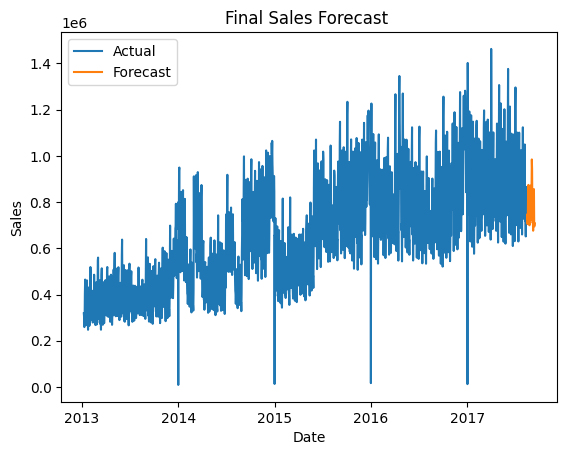

In [30]:
plt.figure()
plt.plot(daily_sales['date'], daily_sales['sales'], label='Actual')
plt.plot(future_df['date'], future_df['predicted_sales'], label='Forecast')

plt.legend()
plt.title("Final Sales Forecast ")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [31]:
plt.savefig("forecast.png")


<Figure size 640x480 with 0 Axes>

In [32]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 54.6 MB/s eta 0:00:00


In [34]:
!streamlit run app.py &>/content/logs.txt &

In [35]:
!cat /content/logs.txt



2026-09-29 16:19:16.579 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.105.22.102:8501



In [36]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://127.0.0.1:8501

2026-09-29T16:24:10Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-29T16:24:10Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-29T16:24:14Z INF +--------------------------------------------------------------------------------------------+
2026-09-29T16:24:14Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-29T16:24:14Z INF |  https://covers-informational-rim-topics.trycloudflare